In [84]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [85]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [86]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering

    # Use the bottom four levels (in Python notation!)
    levels = [-1, -2, -3, -4]
    
    coeffs = np.zeros((4, len(lat), len(lon)))

    # Compute weights using interpolating polynomials
    coeffs[0] = (
        (z_val - h[levels[1]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[0]] - h[levels[1]]) * (h[levels[0]] - h[levels[2]])
        * (h[levels[0]] - h[levels[3]])
    )
    coeffs[1] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[1]] - h[levels[0]]) * (h[levels[1]] - h[levels[2]])
        * (h[levels[1]] - h[levels[3]])
    )
    coeffs[2] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[2]] - h[levels[0]]) * (h[levels[2]] - h[levels[1]])
        * (h[levels[2]] - h[levels[3]])
    )
    coeffs[3] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[2]])
    ) / (
        (h[levels[3]] - h[levels[0]]) * (h[levels[3]] - h[levels[1]])
        * (h[levels[3]] - h[levels[2]])
    )

    field_vals = np.zeros((len(lat), len(lon)))
    
    for i in np.arange(4):
        field_vals += coeffs[i]*field_vals_all[levels[i]]

    # Set values below surface to NaN
    field_vals = np.where(
        h[levels[0]] > z_val, np.nan, field_vals
    )
    
    return field_vals

In [87]:
# If saving:
savefig = True

rot = False

dycore1 = 'CAM-SE'
dycore2 = 'CAM-FV3'
dycore3 = 'CAM-MPAS'
dycore4 = 'GungHo'

res1 = 'se_ne60'
res2 = 'fv3_C192'
res3 = 'mpasa60'

test_name_start1 = 'cam_6_4_100'
test_name_start2 = 'cam_6_4_070_horiz_mount_flow'
test_name_start3 = 'cam_6_4_080_paper_six'


#lev_no1 = 'ztop20km_L57'
#extra_name1 = 'tau_1_10'
#extra_name1 = 'tau_1_10_nsplit4'
#extra_name1 = 'tau_1_10_nsplit4_visc_subcyc_1'
lev_no1 = 'ztop20km_L57_new_RF'
extra_name1='tau_100s'
#extra_name1 = 'tau_100s'
#extra_name1 = 'tau_0s'

#lev_no2 = 'ztop20km_L57'
#extra_name2 = 'tau_1_10_no_vortdamp'
#extra_name2 = 'tau_1_10_no_vortdamp_ksplit2'
#extra_name2 = 'tau_1_10_no_vortdamp_ksplit2_hord5'
lev_no2 = 'ztop20km_L57_new_RF'
extra_name2 = 'tau100s'
#extra_name2 = 'tau200s_taumix90s'
#extra_name2 = 'tau100s'
#extra_name2 = 'tau10s'

#lev_no3 = 'L20km_L57'
#extra_name3 = 'tau_1_10_new_vgrid'
lev_no3 = 'L20km_L57_new_RF_w0'
extra_name3 = 'tau100s'


case1 = f'{test_name_start1}_{res1}_{lev_no1}'
case2 = f'{test_name_start2}_{res2}_{lev_no2}'
case3 = f'{test_name_start3}_{res3}_{lev_no3}'

# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name3}'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name3}'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.regrid.0.5x0.5.nc'  # FV3 needs regridding
nc_file3 = nc_file3 + '.regrid.0.5x0.5.nc'  # MPAS needs regridding

print(nc_file1)
print(nc_file2)
print(nc_file3)

cam_6_4_100_se_ne60_ztop20km_L57_new_RF.cam.h0i.0001-01-01-00000_gap_omega0_tau_100s.nc
cam_6_4_070_horiz_mount_flow_fv3_C192_ztop20km_L57_new_RF.cam.h0i.0001-01-01-00000_gap_omega0_tau100s.regrid.0.5x0.5.nc
cam_6_4_080_paper_six_mpasa60_L20km_L57_new_RF_w0.cam.h0i.0001-01-01-00000_gap_omega0_tau100s.regrid.0.5x0.5.nc


In [88]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)

In [89]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 
lev = nc1['lev'][:]

print(np.size(lat), np.size(lon))

361 720


In [90]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
'''
if rot == True:
    lat_crop_up = 40.
    lat_cent_down = -40.
    lat_ticks = np.linspace(-40.,40.,5)
    
    lon_crop_left = 140.
    lon_crop_right = 280.
    lon_ticks = np.linspace(140, 280, 8)
else:
    lat_crop_up = 50.
    lat_cent_down = -50.
    lat_ticks = np.linspace(-40, 40, 5)

    lon_crop_left = 160.
    lon_crop_right = 280.
    lon_ticks = np.linspace(160, 280, 7)
'''


# Consistent lon lat ranges
lat_crop_up = 50.
lat_cent_down = -50.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 280.
#lon_ticks = np.linspace(140, 280, 8)
lon_ticks = np.array([140,180,220,260])

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)
LONcross, LEV = np.meshgrid(lon_crop, lev)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(281,)


In [91]:
# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [92]:
# Vertical slices

eq_lat = 180
print(lat[eq_lat])

lat_val=0

# Cubic interpolation
U_field_vals1 = nc1['U'][t_idx, :, eq_lat, lon_inds] 
U_field_vals2 = nc2['U'][t_idx, :, eq_lat, lon_inds] 
U_field_vals3 = nc3['U'][t_idx, :, eq_lat, lon_inds] 

# Cubic interpolation
T_field_vals1 = nc1['T'][t_idx, :, eq_lat, lon_inds] 
T_field_vals2 = nc2['T'][t_idx, :, eq_lat, lon_inds] 
T_field_vals3 = nc3['T'][t_idx, :, eq_lat, lon_inds] 

0.0


In [93]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (U_field_vals1 - u0*np.cos(lat_val*deg2rad))/(u0*np.cos(lat_val*deg2rad))
U_field_vals2 = (U_field_vals2 - u0*np.cos(lat_val*deg2rad))/(u0*np.cos(lat_val*deg2rad))
U_field_vals3 = (U_field_vals3 - u0*np.cos(lat_val*deg2rad))/(u0*np.cos(lat_val*deg2rad))

# Temperature perturbation:
T_field_vals1 = T_field_vals1 - T0
T_field_vals2 = T_field_vals2 - T0
T_field_vals3 = T_field_vals3 - T0

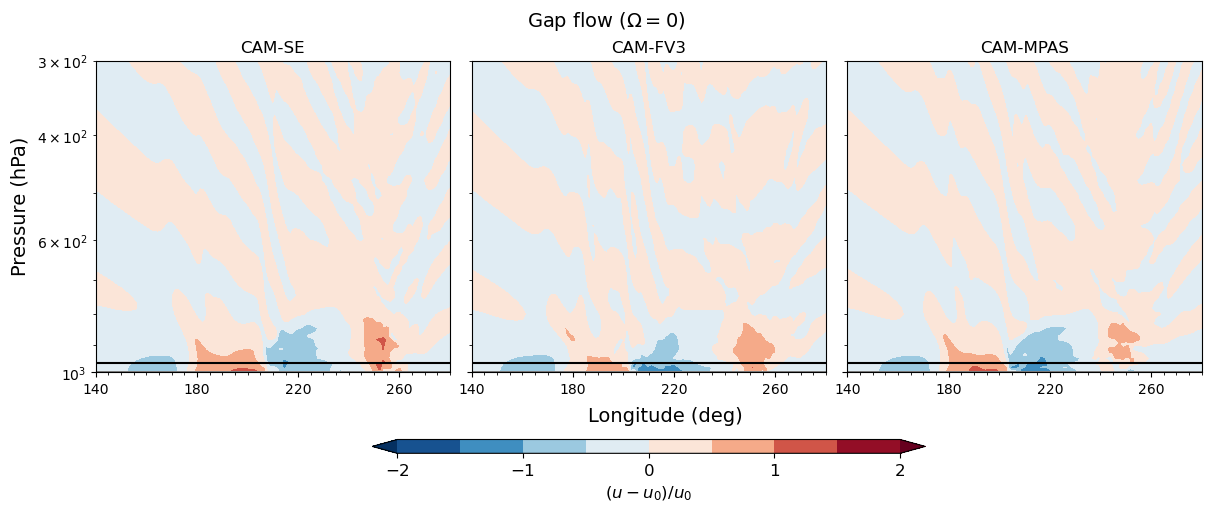

In [94]:
# Plot for U
U_cmap = matplotlib.cm.RdBu_r
U_conts = np.linspace(-2.0, 2.0, 9)
tick_range = np.linspace(-2.0, 2.0, 5)
norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)

fig, axes = plt.subplots(1,3,figsize = (12,5), sharey=True, constrained_layout=True)
(ax1, ax2, ax3) = axes


plot1 = ax1.contourf(LONcross, LEV, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LONcross, LEV, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LONcross, LEV, U_field_vals3, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_facecolor("grey")

    ax.set_xticks(lon_ticks)

    ax.invert_yaxis()
    ax.set_yscale('log')
    ax.set_ylim([1000,300])

cb = plt.colorbar(plot3, ax=axes, ticks = tick_range, shrink=0.5, pad=0.12, aspect=40, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore1}')
ax2.set_title(f'{dycore2}')
ax3.set_title(f'{dycore3}')

# pressure at z=300m for the isothermal atmosphere.
p_300 = 965

ax1.plot(lon_crop, p_300*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, p_300*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, p_300*np.ones_like(lon_crop), c='k')

fig.supylabel('Pressure (hPa)', size=label_size, y=0.6)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.55, y=0.16)

if rot:
    fig.suptitle(r'Gap flow ($\Omega\neq0$)', size=14)
else:
    fig.suptitle(r'Gap flow ($\Omega=0$)', size=14)

In [95]:
Break!

SyntaxError: invalid syntax (3957013180.py, line 1)

In [ ]:
#Lat vert cross sections:
p0 = 1e5
Rd = 287.04
g = 9.80616
H = Rd*T0/g

lon = nc1['lon'][:] 
lat = nc1['lat'][:] 

lev1 = nc1['lev'][:] 
lev2 = nc2['lev'][:]

# MPAS lev is pressure, so convert to z:
mpas_ps = nc3['PS'][:]
mpas_z = nc3['lev'][:]
lev3 = 0.01*p0*np.exp(-mpas_z/H)

lon_crop_left = 150
lon_crop_right = 300

# User parameters:
t_idx = 40
field = 'W'

lon_ticks = np.linspace(lon_crop_left, lon_crop_right, 5)

lon_crop_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))
lon_crop = lon[lon_crop_inds]

LONGC1, P1 = np.meshgrid(lon_crop, lev1) 
LONGC2, P2 = np.meshgrid(lon_crop, lev2) 
LONGC3, P3 = np.meshgrid(lon_crop, lev3) 

# Pick the latitude to slice at:
#lat_val = 95
lat_val = 180

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)


if field=='W':
    Rd = 287.04
    g = 9.80616
    # Convert P from hPa to Pa
    field1 = -(Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P1*100)
    field2 = -(Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P2*100)
    field3 = -(Rd/g)*nc3['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc3['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P3*100)
else:
    field1 = nc1[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field2 = nc2[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field3 = nc3[field][t_idx, :, lat_val, lon_crop_inds[0]]

ps_t = nc1['PS'][t_idx, lat_val, lon_crop_inds[0]]/100

cmap_choice = 'coolwarm'

In [ ]:
max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1

#minmin = -1
#maxmax = 1

absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)
plot1 = ax1.contourf(LONGC1, P1, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC2, P2, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC3, P3, field3, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

cb = plt.colorbar(plot3,ax=axes,pad=0.05,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label('m/s', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82
pc_low =552.4

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

ax1.set_title(f'{dycore1} \n \n min = {min1:.2f} m/s \n max = {max1:.2f} m/s', size=label_size)
ax2.set_title(f'{dycore2} \n \n min = {min2:.2f} m/s \n max = {max2:.2f} m/s', size=label_size)
ax3.set_title(f'{dycore3} \n \n min = {min3:.2f} m/s \n max = {max3:.2f} m/s', size=label_size)